In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import cross_val_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

In [2]:
spotify_high_pop = pd.read_csv("/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/high_popularity_spotify_data.csv")
spotify_high_pop.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,instrumentalness,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,0.0000,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,0.0608,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0.0000,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,0.0000,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,0.0000,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M


In [3]:
spotify_low_pop = pd.read_csv('/Users/donyabehroozi/Documents/gsb545/GSB-545/Project Files/low_popularity_spotify_data.csv')
spotify_low_pop.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,track_album_id,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,4A8gFwqd9jTtnsNwUu3OQx,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,2c965LEDRNrXXCeBOAAwns,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,3S404OgKoVQSJ3xXrDVlp8,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition)
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,1y5KGkUKO0NG32MhIIagCA,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella"
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,6f4b9wVTkKAf096k4XG6x5,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter


In [4]:
#make binary popular variable (1 = popular track, 0 = not a popular track)
spotify_high_pop["popular"] = 1
spotify_high_pop.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popular
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0,6,251668,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1,2,210373,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1,1,166300,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0,0,157280,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0,0,169917,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


In [5]:
#make binary popular variable (1 = popular track, 0 = not a popular track)
spotify_low_pop["popular"] = 0
spotify_low_pop.head()

,time_signature,track_popularity,speechiness,danceability,playlist_name,track_artist,duration_ms,energy,playlist_genre,playlist_subgenre,...,playlist_id,track_id,valence,key,tempo,loudness,acousticness,liveness,track_album_name,popular
0,4.0,23,0.0393,0.636,Rock Classics,Creedence Clearwater Revival,138053.0,0.746,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5e6x5YRnMJIKvYpZxLqdpH,0.432,0.0,132.310,-3.785,0.0648,0.1730,The Long Road Home - The Ultimate John Fogerty...,0
1,4.0,53,0.0317,0.572,Rock Classics,Van Halen,241600.0,0.835,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5FqYA8KfiwsQvyBI4IamnY,0.795,0.0,129.981,-6.219,0.1710,0.0702,The Collection,0
2,4.0,55,0.0454,0.591,Rock Classics,Stevie Nicks,329413.0,0.804,rock,classic,...,37i9dQZF1DWXRqgorJj26U,5LNiqEqpDc8TuqPy79kDBu,0.658,0.0,111.457,-7.299,0.3270,0.0818,Bella Donna (Deluxe Edition),0
3,4.0,64,0.1010,0.443,Jazz Classics,"Ella Fitzgerald, Louis Armstrong",185160.0,0.104,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,78MI7mu1LV1k4IA2HzKmHe,0.394,0.0,76.474,-17.042,0.9130,0.1910,"Love, Ella",0
4,4.0,62,0.0298,0.685,Jazz Classics,Galt MacDermot,205720.0,0.472,jazz,classic,...,37i9dQZF1DXbITWG1ZJKYt,6MN6yRVriszuyAVlyF8ndB,0.475,9.0,80.487,-9.691,0.7850,0.2240,Shapes of Rhythm/Woman Is Sweeter,0


In [6]:
#concatenate high and low popularity datasets
spotify_full = pd.concat([spotify_high_pop, spotify_low_pop], axis=0).reset_index(drop=True)
spotify_full.head()

,energy,tempo,danceability,playlist_genre,loudness,liveness,valence,track_artist,time_signature,speechiness,...,track_album_id,mode,key,duration_ms,acousticness,id,playlist_subgenre,type,playlist_id,popular
0,0.592,157.969,0.521,pop,-7.777,0.122,0.535,"Lady Gaga, Bruno Mars",3.0,0.0304,...,10FLjwfpbxLmW8c25Xyc2N,0.0,6.0,251668.0,0.3080,2plbrEY59IikOBgBGLjaoe,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
1,0.507,104.978,0.747,pop,-10.171,0.117,0.438,Billie Eilish,4.0,0.0358,...,7aJuG4TFXa2hmE4z1yxc3n,1.0,2.0,210373.0,0.2000,6dOtVTDdiauQNBQEDOtlAB,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
2,0.808,108.548,0.554,pop,-4.169,0.159,0.372,Gracie Abrams,4.0,0.0368,...,0hBRqPYPXhr1RkTDG3n4Mk,1.0,1.0,166300.0,0.2140,7ne4VBA60CxGM75vw0EYad,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
3,0.910,112.966,0.670,pop,-4.070,0.304,0.786,Sabrina Carpenter,4.0,0.0634,...,4B4Elma4nNDUyl6D5PvQkj,0.0,0.0,157280.0,0.0939,1d7Ptw3qYcfpdLNL5REhtJ,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1
4,0.783,149.027,0.777,pop,-4.477,0.355,0.939,"ROSÉ, Bruno Mars",4.0,0.2600,...,2IYQwwgxgOIn7t3iF6ufFD,0.0,0.0,169917.0,0.0283,5vNRhkKd0yEAg8suGBpjeY,mainstream,audio_features,37i9dQZF1DXcBWIGoYBM5M,1


## EDA

In [7]:
#examine shape of data
spotify_full.shape

(4831, 30)

In [8]:
# check data types
spotify_full.dtypes

energy                      float64
tempo                       float64
danceability                float64
playlist_genre                  str
loudness                    float64
liveness                    float64
valence                     float64
track_artist                    str
time_signature              float64
speechiness                 float64
track_popularity              int64
track_href                      str
uri                             str
track_album_name                str
playlist_name                   str
analysis_url                    str
track_id                        str
track_name                      str
track_album_release_date        str
instrumentalness            float64
track_album_id                  str
mode                        float64
key                         float64
duration_ms                 float64
acousticness                float64
id                              str
playlist_subgenre               str
type                        

In [9]:
#check for missing values
spotify_full.isna().sum()

energy                      1
tempo                       1
danceability                1
playlist_genre              0
loudness                    1
liveness                    1
valence                     1
track_artist                0
time_signature              1
speechiness                 1
track_popularity            0
track_href                  1
uri                         1
track_album_name            1
playlist_name               0
analysis_url                1
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            1
track_album_id              0
mode                        1
key                         1
duration_ms                 1
acousticness                1
id                          1
playlist_subgenre           0
type                        1
playlist_id                 0
popular                     0
dtype: int64

In [10]:
#drop NAs because there are so few
spotify_full = spotify_full.dropna()
spotify_full.isna().sum()

energy                      0
tempo                       0
danceability                0
playlist_genre              0
loudness                    0
liveness                    0
valence                     0
track_artist                0
time_signature              0
speechiness                 0
track_popularity            0
track_href                  0
uri                         0
track_album_name            0
playlist_name               0
analysis_url                0
track_id                    0
track_name                  0
track_album_release_date    0
instrumentalness            0
track_album_id              0
mode                        0
key                         0
duration_ms                 0
acousticness                0
id                          0
playlist_subgenre           0
type                        0
playlist_id                 0
popular                     0
dtype: int64

In [11]:
print(spotify_full.shape)

(4829, 30)


In [12]:
#check for duplicates
spotify_full.duplicated().sum()

np.int64(0)

In [13]:
# some data preprocessing

# extract release year from track_album_release_date
spotify_full['release_year'] = pd.to_datetime(
    spotify_full['track_album_release_date'], errors='coerce').dt.year

In [14]:
spotify_full.isna().sum()

energy                        0
tempo                         0
danceability                  0
playlist_genre                0
loudness                      0
liveness                      0
valence                       0
track_artist                  0
time_signature                0
speechiness                   0
track_popularity              0
track_href                    0
uri                           0
track_album_name              0
playlist_name                 0
analysis_url                  0
track_id                      0
track_name                    0
track_album_release_date      0
instrumentalness              0
track_album_id                0
mode                          0
key                           0
duration_ms                   0
acousticness                  0
id                            0
playlist_subgenre             0
type                          0
playlist_id                   0
popular                       0
release_year                138
dtype: i

In [15]:
# find rows where release_year is NaN (i.e. date couldn't be parsed)
mask = spotify_full['release_year'].isna()
print(spotify_full.loc[mask, 'track_album_release_date'].value_counts())

track_album_release_date
1998       10
1996        9
2005        8
2012        8
2010        7
1977        6
2000        6
2004        5
2001        5
1976        4
1982        4
1995        4
2003        4
2002        4
2006        4
1992        3
1983        3
2007        3
1999        3
1994        3
2014        3
2008        3
1997        3
1979        2
1986        2
1981        2
1985        2
1975        2
2015        2
1990        2
2011        2
1970        1
1973        1
1971        1
1984        1
1980        1
1979-06     1
1978        1
1972        1
2013        1
1991        1
Name: count, dtype: int64


In [16]:
#fix problematic release years
def parse_release_year(date_str):
    if pd.isna(date_str):
        return None
    date_str = str(date_str).strip()
    # handle year only (e.g. "1998") or year-month (e.g. "1979-06")
    try:
        return pd.to_datetime(date_str).year
    except:
        return None

spotify_full['release_year'] = spotify_full['track_album_release_date'].apply(parse_release_year)
print(spotify_full['release_year'].isna().sum())

0


In [17]:
# drop irrelevant columns
drop_cols = ['track_artist', 'track_href', 'uri', 'track_album_name', 
             'playlist_name', 'analysis_url', 'track_id', 'track_name',
             'track_album_id', 'id', 'type', 'playlist_id',
             'track_album_release_date',  # replaced by release_year
             'track_popularity']  # drops leaky variable

spotify_full = spotify_full.drop(columns=drop_cols)

In [18]:
#quantitative variables summary statistics
spotify_full.describe()

,energy,tempo,danceability,loudness,liveness,valence,time_signature,speechiness,instrumentalness,mode,key,duration_ms,acousticness,popular,release_year
count,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4829.000000,4.829000e+03,4829.000000,4829.000000,4829.000000
mean,0.586621,118.271840,0.622299,-9.283028,0.167609,0.481851,3.936633,0.101747,0.201094,0.562228,5.233796,2.061598e+05,0.341279,0.348934,2016.760199
std,0.246240,28.515018,0.187723,7.129469,0.124442,0.258006,0.409753,0.101040,0.351943,0.496164,3.581084,8.175164e+04,0.325387,0.476682,10.729003
min,0.000202,48.232000,0.058900,-48.069000,0.021000,0.029600,1.000000,0.021900,0.000000,0.000000,0.000000,3.537500e+04,0.000004,0.000000,1954.000000
25%,0.442000,96.063000,0.525000,-10.298000,0.095400,0.275000,4.000000,0.038600,0.000000,0.000000,2.000000,1.590000e+05,0.053000,0.000000,2015.000000
50%,0.633000,118.068000,0.653000,-7.191000,0.118000,0.483000,4.000000,0.056100,0.000092,1.000000,5.000000,1.948800e+05,0.225000,0.000000,2022.000000
75%,0.777000,136.732000,0.758000,-5.339000,0.195000,0.690000,4.000000,0.118000,0.201000,1.000000,8.000000,2.334780e+05,0.590000,1.000000,2024.000000
max,0.998000,241.426000,0.979000,1.318000,0.979000,0.987000,5.000000,0.927000,0.991000,1.000000,11.000000,1.355260e+06,0.996000,1.000000,2024.000000


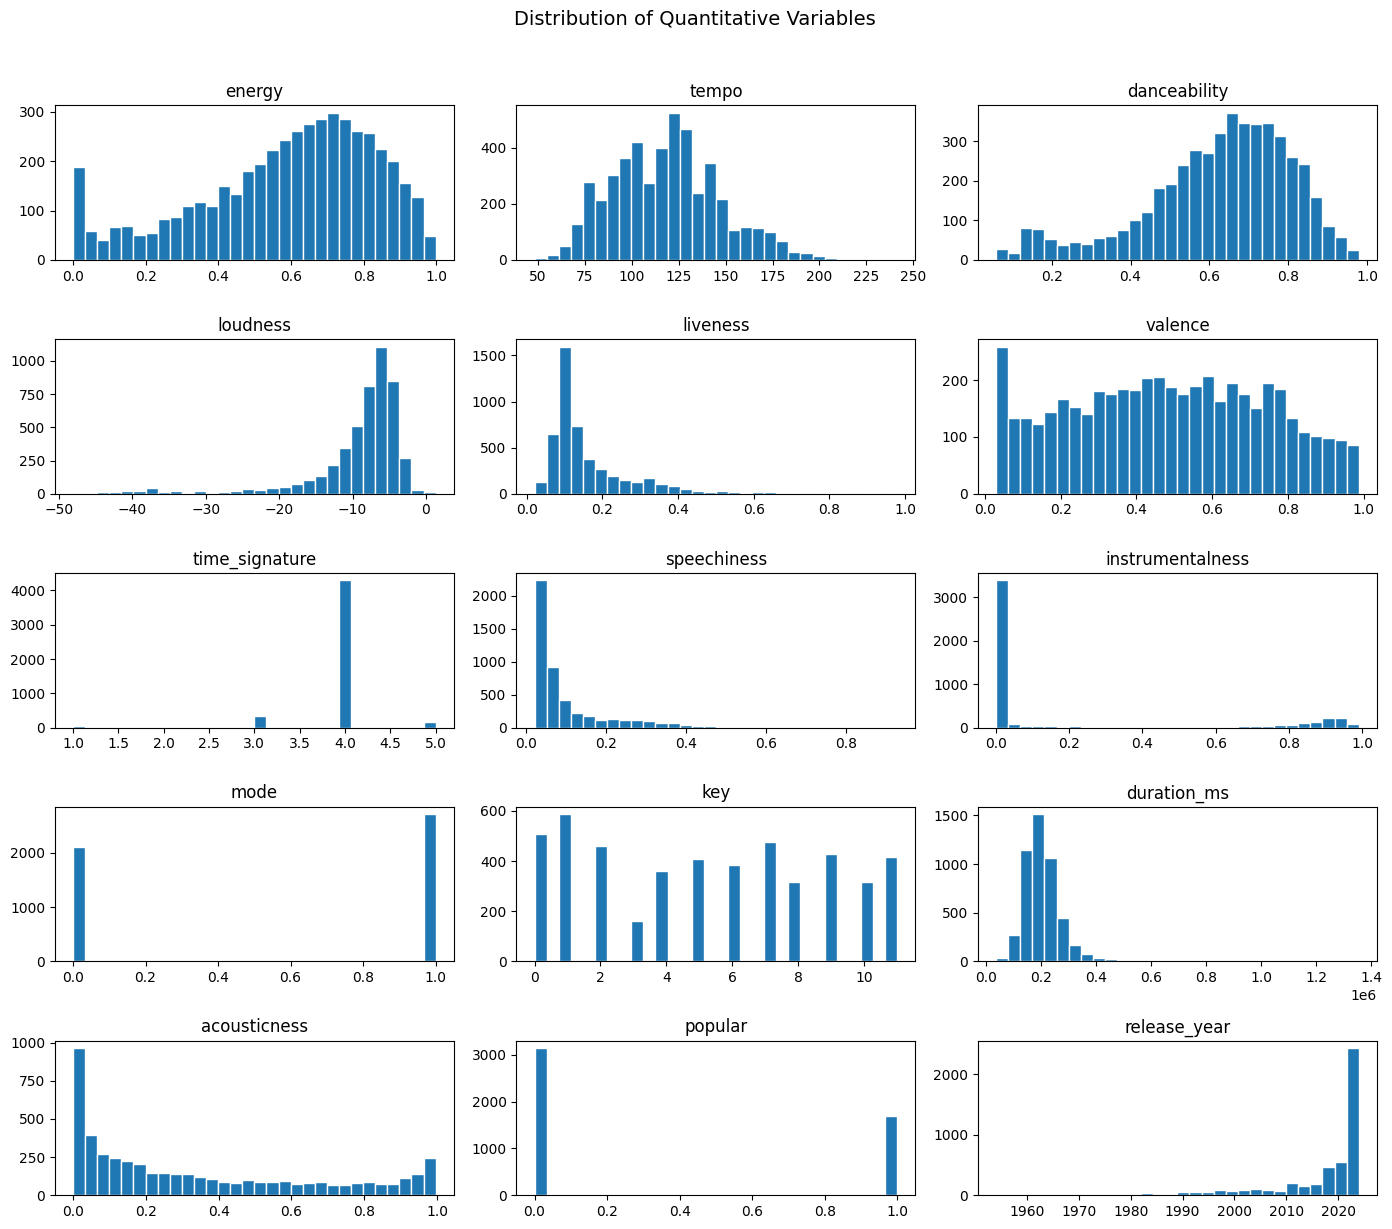

In [19]:
#visualization of quantitative variables
quant_vars = [
    'energy', 'tempo', 'danceability', 'loudness',
    'liveness', 'valence', 'time_signature',
    'speechiness', 'instrumentalness',
    'mode', 'key', 'duration_ms', 'acousticness', 'popular', 'release_year'
]

fig, axes = plt.subplots(5, 3, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(quant_vars):
    axes[i].hist(spotify_full[var], bins=30, edgecolor='white')
    axes[i].set_title(var)
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Quantitative Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('histogram_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
#check balance of target variable
spotify_full["popular"].value_counts(normalize = True)

popular
0    0.651066
1    0.348934
Name: proportion, dtype: float64

**Quick insights:**
- Target variable (whether a song is popular or not) is imbalanced
- Most distributions are skewed except for duration, valence, and tempo
- Most songs were released recently

In [21]:
#categorical variable summary
spotify_full.describe(include = ['str'])

,playlist_genre,playlist_subgenre
count,4829,4829
unique,35,84
top,electronic,modern
freq,589,694


Way too granular. I need to collapse these categorical variables a bit.

In [22]:
print(spotify_full['playlist_genre'].value_counts())
with pd.option_context('display.max_rows', 100):
    print(spotify_full['playlist_subgenre'].value_counts())

playlist_genre
electronic    589
pop           515
latin         425
hip-hop       395
ambient       359
rock          345
lofi          298
world         228
arabic        208
brazilian     148
jazz          146
gaming        133
classical     121
blues          88
afrobeats      82
wellness       80
punk           74
turkish        71
folk           68
indian         57
r&b            50
metal          49
soul           44
gospel         39
korean         34
funk           28
cantopop       27
reggae         24
j-pop          23
indie          17
k-pop          16
mandopop       14
soca           14
country        11
disco           9
Name: count, dtype: int64
playlist_subgenre
modern            694
chill             419
classic           293
meditative        231
french            161
reggaeton         158
throwback         150
scandi            134
hip-hop           125
jewish            101
soft               98
yoga               80
nordic             78
forró              74
pop

In [23]:
#collapse playlist genres and subgenres
genre_map = {
    # Electronic/Dance
    'electronic': 'electronic', 'ambient': 'electronic', 'lofi': 'electronic',
    'gaming': 'electronic', 'disco': 'electronic',
    
    # Pop/Mainstream
    'pop': 'pop', 'indie': 'pop', 'k-pop': 'pop', 'j-pop': 'pop',
    'cantopop': 'pop', 'mandopop': 'pop',
    
    # Hip-Hop/R&B/Soul
    'hip-hop': 'hip-hop_rnb', 'r&b': 'hip-hop_rnb', 'soul': 'hip-hop_rnb',
    'funk': 'hip-hop_rnb',
    
    # Latin/World
    'latin': 'latin_world', 'world': 'latin_world', 'arabic': 'latin_world',
    'brazilian': 'latin_world', 'afrobeats': 'latin_world', 'turkish': 'latin_world',
    'indian': 'latin_world', 'korean': 'latin_world', 'soca': 'latin_world',
    'reggae': 'latin_world',
    
    # Rock/Metal/Punk
    'rock': 'rock_metal', 'metal': 'rock_metal', 'punk': 'rock_metal',
    
    # Jazz/Blues/Gospel
    'jazz': 'jazz_blues', 'blues': 'jazz_blues', 'gospel': 'jazz_blues',
    
    # Classical/Folk/Acoustic
    'classical': 'classical_folk', 'folk': 'classical_folk',
    
    # Wellness/Lifestyle
    'wellness': 'wellness', 'country': 'wellness'
}

spotify_full['playlist_genre'] = spotify_full['playlist_genre'].map(genre_map)

subgenre_map = {
    # Chill/Relaxed
    'chill': 'chill', 'lofi': 'chill', 'meditative': 'chill',
    'yoga': 'chill', 'soft': 'chill', 'bedroom': 'chill', 'smooth': 'chill',
    
    # Modern/Mainstream
    'modern': 'modern', 'mainstream': 'modern', 'pop': 'modern',
    'feel-good': 'modern', 'essential': 'modern',
    
    # Classic/Throwback
    'classic': 'classic', 'throwback': 'classic', '80s': 'classic',
    '90s': 'classic', 'retro': 'classic',
    
    # Hip-Hop/Urban
    'hip-hop': 'urban', 'trap': 'urban', 'gangster': 'urban',
    'drill': 'urban', 'grime': 'urban',
    
    # Electronic/Dance
    'deep house': 'electronic', 'techno': 'electronic', 'hardstyle': 'electronic',
    'future': 'electronic', 'vaporwave': 'electronic', 'future bass': 'electronic',
    'afro house': 'electronic',
    
    # Latin/Tropical
    'reggaeton': 'latin', 'tropical': 'latin', 'afro-latin': 'latin',
    'cumbia': 'latin', 'samba': 'latin', 'forró': 'latin',
    'carnival': 'latin',
    
    # World/Global
    'french': 'world', 'scandi': 'world', 'nordic': 'world',
    'african': 'world', 'global': 'world', 'chinese': 'world',
    'japanese': 'world', 'nigerian': 'world', 'desi': 'world',
    'bhangra': 'world', 'bollywood': 'world', 'amapiano': 'world',
    'gqom': 'world', 'throat singing': 'world', 'australian': 'world',
    'celtic': 'world', 'irish': 'world', 'indigenous': 'world',
    'klezmer': 'world', 'jewish': 'world', 'tango': 'world',
    'cajun': 'world', 'southern': 'world', 'american': 'world',
    
    # Classical/Acoustic
    'classical': 'classical', 'neo-classical': 'classical', 'choral': 'classical',
    'cinematic': 'classical', 'academic': 'classical', 'soundtracks': 'classical',
    'noir': 'classical', 'drama': 'classical',
    
    # Alternative/Indie
    'alternative': 'alternative', 'indie': 'alternative', 'pop punk': 'alternative',
    'death': 'alternative', 'heavy': 'alternative', 'experimental': 'alternative',
    'post-rock': 'alternative', 'avant-garde': 'alternative',
    
    # Other
    'funk': 'other', 'melodic': 'other', 'workout': 'other',
    'anime': 'other', 'italo': 'other', 'delta': 'other',
    'fusion': 'other', 'latin': 'other', 'spanish': 'other',
    'afrobeats': 'other'
}

spotify_full['playlist_subgenre'] = spotify_full['playlist_subgenre'].map(subgenre_map)

# verify no NaNs from unmapped values
print(spotify_full['playlist_genre'].value_counts())
print(spotify_full['playlist_subgenre'].value_counts())
print(spotify_full[['playlist_genre', 'playlist_subgenre']].isna().sum())

playlist_genre
electronic        1388
latin_world       1291
pop                612
hip-hop_rnb        517
rock_metal         468
jazz_blues         273
classical_folk     189
wellness            91
Name: count, dtype: int64
playlist_subgenre
modern         913
world          896
chill          893
classic        557
latin          390
urban          294
electronic     248
alternative    221
classical      212
other          205
Name: count, dtype: int64
playlist_genre       0
playlist_subgenre    0
dtype: int64


In [24]:
#categorical variable summary after collapsing
spotify_full.describe(include = ['str'])

,playlist_genre,playlist_subgenre
count,4829,4829
unique,8,10
top,electronic,modern
freq,1388,913


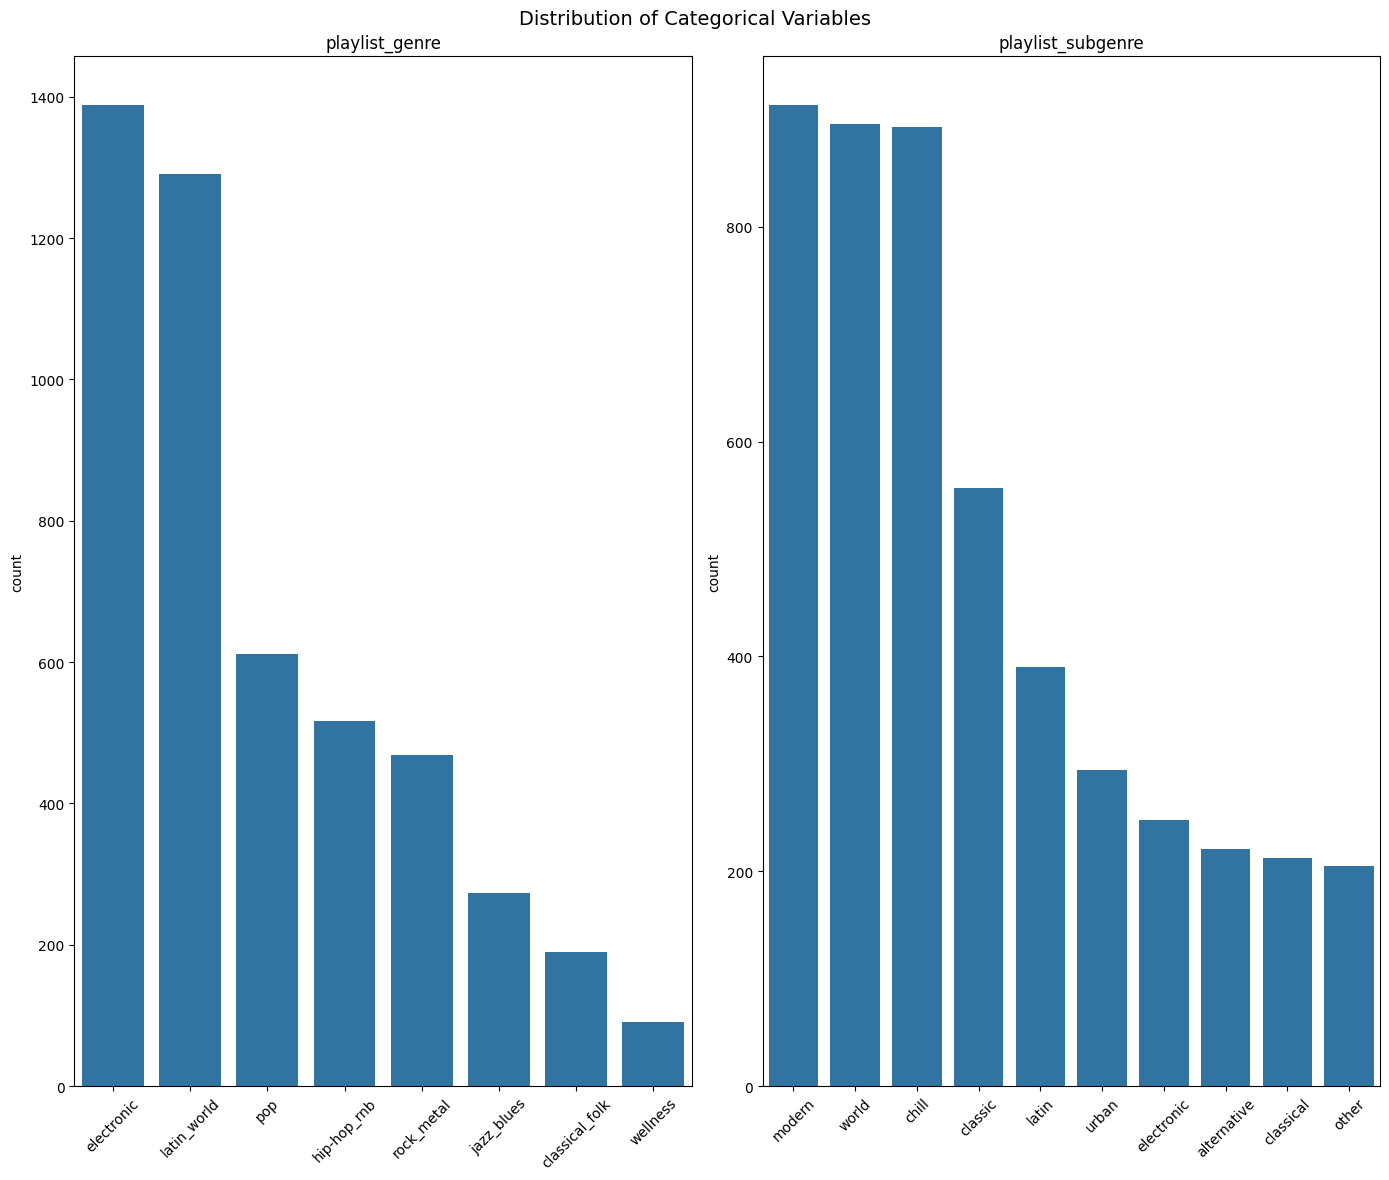

In [25]:
cat_vars = [
    'playlist_genre', 'playlist_subgenre'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 12))
axes = axes.flatten()

for i, var in enumerate(cat_vars):
    order = spotify_full[var].value_counts().index  # sort bars by frequency
    sns.countplot(data=spotify_full, x=var, ax=axes[i], order=order)
    axes[i].set_title(var)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Variables', fontsize=14)
plt.tight_layout()
plt.savefig('categorical_panel.png', dpi=150, bbox_inches='tight')
plt.show()

In [119]:
#sweetviz to show visual of associations between variables
project_report_spotify = sv.analyze(spotify_full)
project_report_spotify.show_html('project_report_spotify.html')

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report project_report_spotify.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


## Data preprocessing for modeling

In [26]:
quant_vars = [
    'energy', 'tempo', 'danceability', 'loudness',
    'liveness', 'valence', 'time_signature',
    'speechiness', 'instrumentalness',
    'mode', 'key', 'duration_ms', 'acousticness', 'release_year'
]

y = spotify_full['popular']

# one-hot encode categorical variables
X = pd.concat([
    spotify_full[quant_vars],
    pd.get_dummies(spotify_full[cat_vars], drop_first=True).astype(int)
], axis=1)

# train + test + validation split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=321)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, stratify=y_train_full, test_size=0.2, random_state=321)

# scaled variables for logistic regression and multilayer perceptron
scaler = MinMaxScaler()
X_train_scaled = X_train.copy()
X_val_scaled   = X_val.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[quant_vars] = scaler.fit_transform(X_train[quant_vars])
X_val_scaled[quant_vars]   = scaler.transform(X_val[quant_vars])
X_test_scaled[quant_vars]  = scaler.transform(X_test[quant_vars])

## Baseline modeling

In [30]:
#model definitions

#Random Forest
rf_model = RandomForestClassifier(random_state=321, class_weight='balanced', n_jobs=-1)

#Extra Trees
et_model = ExtraTreesClassifier(class_weight='balanced', random_state=321, n_jobs=-1)

#XGBoost
xgb_model = XGBClassifier(scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                           random_state=321, eval_metric='auc')

#LightGBM
lgbm_model = LGBMClassifier(class_weight='balanced', random_state=321, n_jobs=-1, verbose=-1)

#Logistic Regression
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=321)

#Naive Bayes
nb_model = GaussianNB()

#MLP
tf.random.set_seed(321)

input_dim = X_train_scaled.shape[1]
inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation='relu')(inputs)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs=inputs, outputs=outputs, name="spotify_popularity_mlp")

In [31]:
#define cross validation method
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=321)

In [32]:
#evaluate models - Random Forest
cv_scores_rf = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_rf)
print(cv_scores_rf.mean())
print(cv_scores_rf.std())

rf_model.fit(X_train, y_train)

y_proba = rf_model.predict_proba(X_val)[:,1]
print("Random Forest Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, rf_model.predict(X_val)))

[0.90195049 0.89135553 0.90506956 0.89864912 0.89097913]
0.8976007652144784
0.005632956346634261
Random Forest Baseline ROC AUC: 0.9018113540976364
              precision    recall  f1-score   support

           0       0.84      0.94      0.88       503
           1       0.85      0.66      0.74       270

    accuracy                           0.84       773
   macro avg       0.84      0.80      0.81       773
weighted avg       0.84      0.84      0.83       773



In [33]:
#evaluate models - Extra Trees
cv_scores_et = cross_val_score(et_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_et)
print(cv_scores_et.mean())
print(cv_scores_et.std())

et_model.fit(X_train, y_train)

y_proba = et_model.predict_proba(X_val)[:,1]
print("Extra Trees Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, et_model.predict(X_val)))

[0.89953835 0.89557966 0.90564538 0.90075088 0.88385618]
0.8970740903536042
0.007348534429084348
Extra Trees Baseline ROC AUC: 0.8978278477284442
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       503
           1       0.85      0.72      0.78       270

    accuracy                           0.86       773
   macro avg       0.85      0.83      0.84       773
weighted avg       0.86      0.86      0.85       773



In [34]:
#evaluate models - XGBoost
cv_scores_xgb = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_xgb)
print(cv_scores_xgb.mean())
print(cv_scores_xgb.std())

xgb_model.fit(X_train, y_train)

y_proba = xgb_model.predict_proba(X_val)[:,1]
print("XGBoost Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, xgb_model.predict(X_val)))

[0.88376132 0.8954354  0.88588884 0.89048392 0.88218629]
0.8875511557652989
0.004830533441738307
XGBoost Baseline ROC AUC: 0.9075546719681908
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       503
           1       0.78      0.78      0.78       270

    accuracy                           0.85       773
   macro avg       0.83      0.83      0.83       773
weighted avg       0.85      0.85      0.85       773



In [35]:
#evaluate models - LGBM
cv_scores_lgbm = cross_val_score(lgbm_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lgbm)
print(cv_scores_lgbm.mean())
print(cv_scores_lgbm.std())

lgbm_model.fit(X_train, y_train)

y_proba = lgbm_model.predict_proba(X_val)[:,1]
print("LightGBM Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lgbm_model.predict(X_val)))

[0.8965953  0.89795141 0.89376612 0.90273747 0.89098489]
0.8964070394219723
0.003971624804303635
LightGBM Baseline ROC AUC: 0.9100139901332744
              precision    recall  f1-score   support

           0       0.90      0.87      0.89       503
           1       0.77      0.81      0.79       270

    accuracy                           0.85       773
   macro avg       0.84      0.84      0.84       773
weighted avg       0.85      0.85      0.85       773



In [36]:
##evaluate models - Logistic Regression
cv_scores_lr = cross_val_score(lr_model, X_train_scaled, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_lr)
print(cv_scores_lr.mean())
print(cv_scores_lr.std())

lr_model.fit(X_train_scaled, y_train)

y_proba = lr_model.predict_proba(X_val_scaled)[:,1]
print("Logistic Regression Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, lr_model.predict(X_val_scaled)))

[0.83893473 0.83146171 0.86511309 0.85336627 0.82476506]
0.8427281742566441
0.014685028769424893
Logistic Regression Baseline ROC AUC: 0.8307414770635447
              precision    recall  f1-score   support

           0       0.83      0.73      0.78       503
           1       0.59      0.73      0.65       270

    accuracy                           0.73       773
   macro avg       0.71      0.73      0.71       773
weighted avg       0.75      0.73      0.73       773



In [37]:
#evaluate models - Naive Bayes
cv_scores_nb = cross_val_score(nb_model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
print(cv_scores_nb)
print(cv_scores_nb.mean())
print(cv_scores_nb.std())

nb_model.fit(X_train, y_train)

y_proba = nb_model.predict_proba(X_val)[:,1]
print("Naive Bayes Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, nb_model.predict(X_val)))

[0.73947141 0.70491084 0.73793648 0.72705339 0.74193846]
0.7302621141529377
0.013660356399927695
Naive Bayes Baseline ROC AUC: 0.732508651792946
              precision    recall  f1-score   support

           0       0.74      0.83      0.78       503
           1       0.58      0.45      0.51       270

    accuracy                           0.70       773
   macro avg       0.66      0.64      0.64       773
weighted avg       0.68      0.70      0.68       773



In [40]:
#evaluate models - MLP
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[keras.metrics.AUC(name='auc')]
)

class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled, y_val),
    class_weight=class_weight_dict,
    verbose=1
)

y_proba = model.predict(X_val_scaled).flatten()
y_pred = (y_proba > 0.5).astype(int)
print("Keras MLP Baseline ROC AUC:", roc_auc_score(y_val, y_proba))
print(classification_report(y_val, y_pred, zero_division=0))

Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - auc: 0.7738 - loss: 0.5811 - val_auc: 0.8034 - val_loss: 0.5199
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - auc: 0.8329 - loss: 0.5022 - val_auc: 0.8285 - val_loss: 0.4908
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 531us/step - auc: 0.8531 - loss: 0.4755 - val_auc: 0.8462 - val_loss: 0.4703
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - auc: 0.8669 - loss: 0.4555 - val_auc: 0.8569 - val_loss: 0.4509
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 534us/step - auc: 0.8771 - loss: 0.4386 - val_auc: 0.8649 - val_loss: 0.4354
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - auc: 0.8850 - loss: 0.4249 - val_auc: 0.8715 - val_loss: 0.4219
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 559us/step - auc: 0.8910 - loss: 0.4136 - val_auc: 0.8756 - val_loss: 0.4139
Epoch 8/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - auc: 0.8959 - loss: 0.4045 - val_auc: 0.8781 - val_loss: 0.4086
Epoch 9/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 535us/step - auc: